In [1]:
import matplotlib
from unbalancedsinkhorn import DebiasedUOT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from matplotlib.colors import TwoSlopeNorm


# Lon Lat 3D Example - including irregular areas

This is very much a tester, and not a polished example. In order to incorrporate the cell areas, you simply multiply by the cell_area array. For accumulation you can simply think that you need to take the mm rain to a volume. 

NOTE: We project into 3D cartisian then calucate the UOT distance etc, so the transport is done in 3D space and through the earth! Not on the sphere surface.

In [2]:

# -----------------------------
# Define Earth grid in degrees
# -----------------------------
lon_res = 3.0
lat_res = 3.0

lon_edges = np.arange(0, 360 + lon_res, lon_res)
lat_edges = np.arange(-90, 90 + lat_res, lat_res)

R = 1.0  # use Earth radius if you want physical units

dlam = np.deg2rad(lon_res)  # constant in longitude
phi = np.deg2rad(lat_edges) # latitude in radians

cell_area = (
    R**2
    * dlam
    * (np.sin(phi[1:]) - np.sin(phi[:-1]))[:, None]
    * np.ones((1, len(lon_edges) - 1))
)

# I now want the centre points of each grid cell
lon_points = 0.5 * (lon_edges[:-1] + lon_edges[1:])
lat_points = 0.5 * (lat_edges[:-1] + lat_edges[1:])
Lon, Lat = np.meshgrid(lon_points, lat_points)

# -----------------------------
# Define two Gaussian fields
# -----------------------------
def gaussian_on_sphere(lon, lat, lon0, lat0, sigma_lon, sigma_lat, amplitude=1.0):
    """
    Gaussian on a longitude-latitude grid (not accounting for spherical distortion).
    """
    return amplitude * np.exp(-(((lon - lon0) / sigma_lon)**2 + ((lat - lat0) / sigma_lat)**2))

central_latitude = 0
central_longitude = 180

# Gaussian 1: center at (60E, 30N)
f1 = gaussian_on_sphere(Lon, Lat, lon0=central_longitude-20, lat0=central_latitude, sigma_lon=5, sigma_lat=15, amplitude=50)
f1[f1 < 1e-3] = 0.0  # threshold small values

# Gaussian 2: center at (240E, -20N)
f2 = gaussian_on_sphere(Lon, Lat, lon0=central_longitude+20, lat0=central_latitude, sigma_lon=15, sigma_lat=10, amplitude=30)
f2[f2 < 1e-3] = 0.0  # threshold small values


# Normalise and scale by cells
f1 = f1 / f1.sum()  # make densities
f2 = f2 / f2.sum()  # make densities

f1 = f1 / cell_area  # scale by cell area
f2 = f2 / cell_area  # scale by cell area

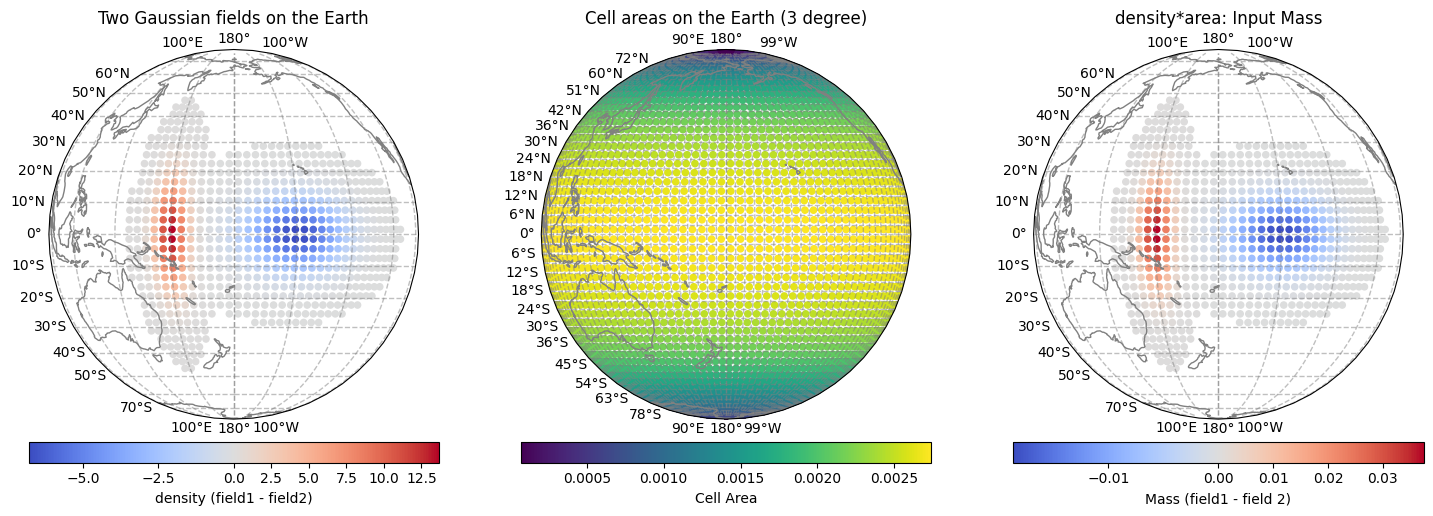

In [3]:
# Plotting
# Define color maps
cmap_b = matplotlib.colors.LinearSegmentedColormap.from_list('rb_cmap', ["white", (0.7, 0.7, 1.0), "blue"], 512)
cmap_r = matplotlib.colors.LinearSegmentedColormap.from_list('rb_cmap', ["white", (1.0, 0.7, 0.7), "red"], 512)

# Blend: multiply the normalized RGBA arrays
f1_rgb = cmap_b(f1)
f2_rgb = cmap_r(f2)
fx = f1_rgb * f2_rgb  # element-wise multiplication - for plotting

# -----------------------------
# Plot on Orthographic projection
# -----------------------------
fig = plt.figure(figsize=(18, 6))

ax = fig.add_subplot(
    1, 3, 1, 
    projection=ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
)
ax.set_global()
plt.title("Two Gaussian fields on the Earth")

mask = (f1 > 1e-3) | (f2 > 1e-3)

# Flatten
lon_f = Lon[mask]
lat_f = Lat[mask]
val_f = f1[mask] - f2[mask]  # example scalar field

norm = TwoSlopeNorm(
    vmin=np.nanmin(val_f),
    vcenter=0.0,
    vmax=np.nanmax(val_f)
)

# Scalar field
sc = ax.scatter(
    lon_f, lat_f,
    c=val_f,
    s=20,
    norm=norm,
    cmap="coolwarm",
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, orientation='horizontal', pad=0.05, label='density (field1 - field2)')

# Add coastlines
ax.coastlines(resolution='110m', color='grey', linestyle='-', alpha=1)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlocator = mticker.FixedLocator(list(np.arange(-180, 181, 20)))
gl.ylocator = mticker.FixedLocator(list(np.arange(-90, 91, 10)))

# second axis
ax = fig.add_subplot(
    1, 3, 2, 
    projection=ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
)
ax.set_global()
plt.title("Cell areas on the Earth (3 degree)")

# Scalar field
sc = ax.scatter(
    Lon, Lat,
    c=cell_area,
    s=20,
    cmap="viridis",
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, orientation='horizontal', pad=0.05, label='Cell Area')

# Add coastlines
ax.coastlines(resolution='110m', color='grey', linestyle='-', alpha=1)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlocator = mticker.FixedLocator(list(np.arange(-180, 181, 3)))
gl.ylocator = mticker.FixedLocator(list(np.arange(-90, 91, 3)))

ax = fig.add_subplot(
    1, 3, 3, 
    projection=ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
)
ax.set_global()
plt.title("density*area: Input Mass")

mask = (f1 > 1e-3) | (f2 > 1e-3)

# Flatten
lon_f = Lon[mask]
lat_f = Lat[mask]
val_f = f1[mask] - f2[mask]  # example scalar field
norm = TwoSlopeNorm(
    vmin=np.nanmin(val_f*cell_area[mask]),
    vcenter=0.0,
    vmax=np.nanmax(val_f*cell_area[mask])
)
# Scalar field
sc = ax.scatter(
    lon_f, lat_f,
    c=val_f*cell_area[mask],
    s=20,
    norm=norm,
    cmap="coolwarm",
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, orientation='horizontal', pad=0.05, label='Mass (field1 - field 2)')

# Add coastlines
ax.coastlines(resolution='110m', color='grey', linestyle='-', alpha=1)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlocator = mticker.FixedLocator(list(np.arange(-180, 181, 20)))
gl.ylocator = mticker.FixedLocator(list(np.arange(-90, 91, 10)))



plt.show()
# fig.savefig('gaussian_earth.png', dpi=300)
# plt.close()


In [4]:
# This is a slightly modified example so that the total acuumulated rain sums to one
f1.sum(), f2.sum(), (f1*cell_area).sum(), (f2*cell_area).sum()

(np.float64(371.33486775133656),
 np.float64(367.62957025877984),
 np.float64(1.0000000000000004),
 np.float64(1.0))

### Project into 3D cart; 

In [5]:
# Lon, Lat from np.meshgrid in degrees
lon_rad = np.deg2rad(Lon)  
lat_rad = np.deg2rad(Lat)

# Cartesian coordinates
X = R * np.cos(lat_rad) * np.cos(lon_rad)
Y = R * np.cos(lat_rad) * np.sin(lon_rad)
Z = R * np.sin(lat_rad)

print(X.shape, Y.shape, Z.shape)  


(60, 120) (60, 120) (60, 120)


In [6]:
# create mesh;
grid = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=-1)  # shape (N, 3)

# Now we can run the unbalanced OT on the projected points

Note: The densities need to be flattened so that pykeops is used by defualt,. Tensoiration for 3D has not (yet) been implemented but can be, although we don't have any regular struture here anyway. 

In [7]:
# epsilon estimate;
print((X[1:, :] - X[:-1, :]).max(), (Y[:, 1:] - Y[:, :-1]).max())

0.0522642316338268 0.05226423163382673


In [8]:

uot_class = DebiasedUOT(pykeops=True) # , cuda_device='cpu')
uot_class.parameters(epsilon=0.05, rho=1.0)
uot_class.densities(
    forecast_density=f1.flatten()*cell_area.flatten(),
    forecast_points=grid,
    observation_density=f2.flatten()*cell_area.flatten(),
    observation_points=grid
    )

output = uot_class.sinkhorn_algorithm(sinkhorn_steps=1000, aprox='kl', tol=1e-9)
se = uot_class.sinkhorn_divergence(tol=1e-9)

output, se


3D works only for pykeops right now - so no tensorisation implemented yet
3D works only for pykeops right now - so no tensorisation implemented yet
Convergence in f, g updates below 1e-09 in 166 iterations
3D works only for pykeops right now - so no tensorisation implemented yet
3D works only for pykeops right now - so no tensorisation implemented yet
3D works only for pykeops right now - so no tensorisation implemented yet
3D works only for pykeops right now - so no tensorisation implemented yet
Convergence in f, g updates below 1e-09 in 48 iterations
Convergence in f, g updates below 1e-09 in 45 iterations


((tensor(9.982223936333412e-10, device='cuda:0', dtype=torch.float64),
  tensor(9.506879727894102e-10, device='cuda:0', dtype=torch.float64),
  166),
 tensor(0.207445671181568, device='cuda:0', dtype=torch.float64))

In [9]:

# Biased vector - Observation to forecast
V0 = uot_class.barycentre_map_of_points("target").cpu()
# Debiasing extra term for V0: V0 - u0 is the debiased vector
u0 = uot_class.debias_f.barycentre_map_of_points("target").cpu()


# Biased vector - Forecast to observation
V1 = uot_class.barycentre_map_of_points("source").cpu()
# Debiasing extra term for V1: V1 - u1 is the debiased vector
u1 = uot_class.debias_g.barycentre_map_of_points("source").cpu()


In [10]:
V1.shape

torch.Size([7200, 3])

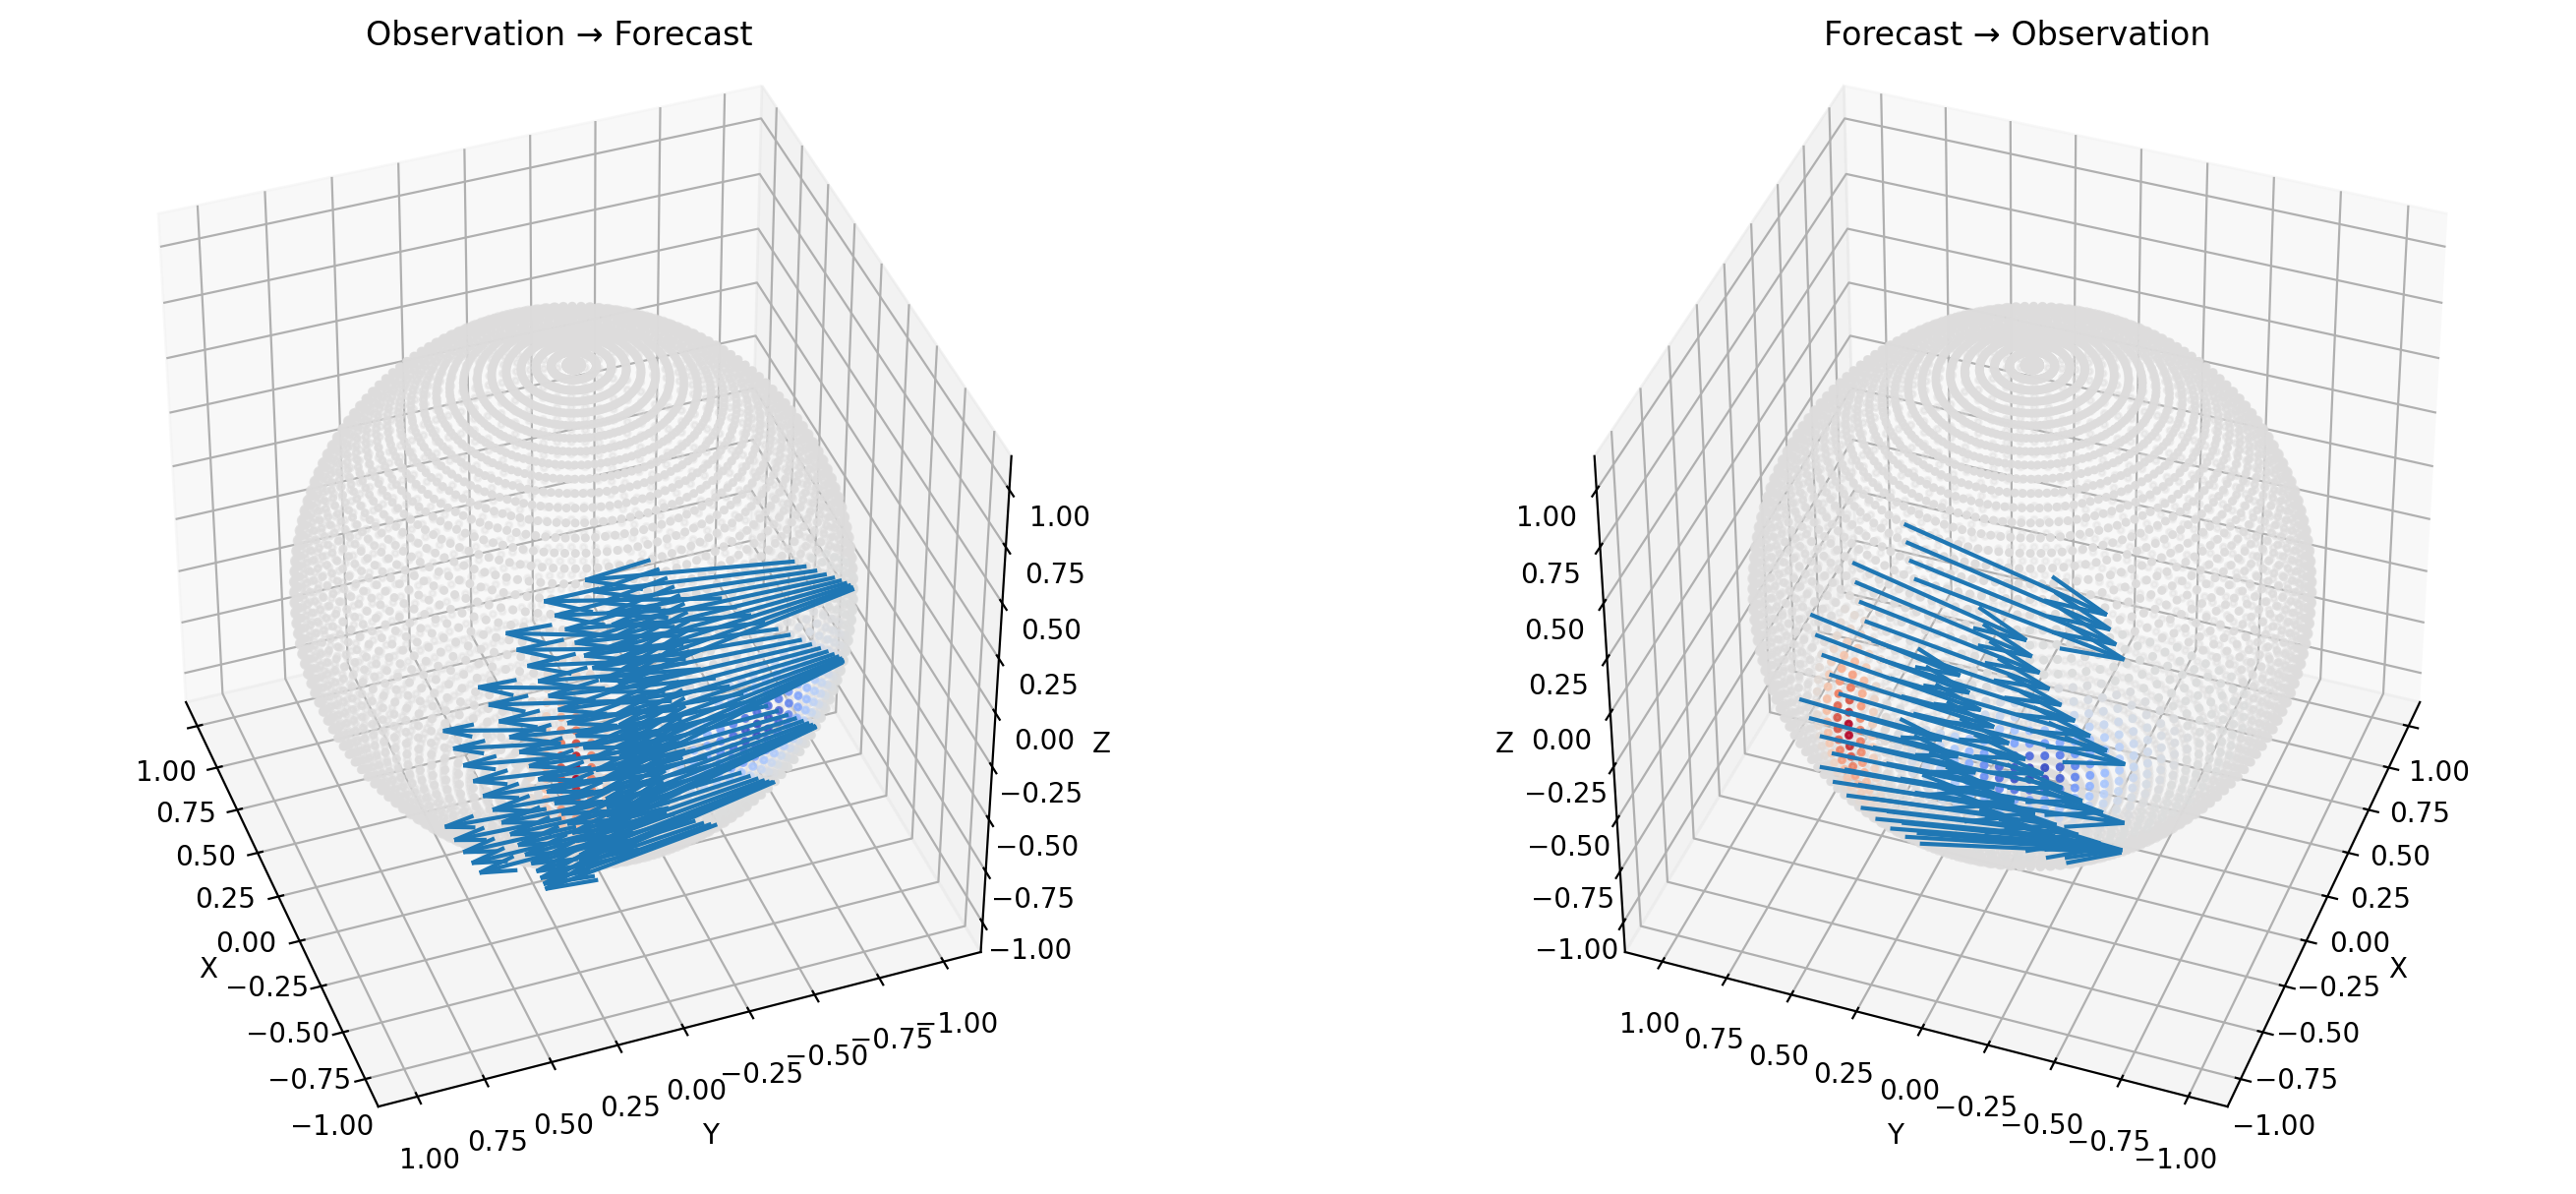

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------------
# INPUT
# ----------------------------------

# Vectors
v0_obs = -(V0 - u0).cpu().numpy()   # (N,3)
v0_fcst = -(V1 - u1).cpu().numpy()  # (N,3)

# Grids (Cartesian coordinates)
X_obs = grid
X_fcst = grid  # (N,3)

# ----------------------------------
# PLOTTING
# ----------------------------------

fig = plt.figure(figsize=(16, 6), dpi=200)
ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")

datasets = [
    (ax1, X_obs, v0_obs, "Observation → Forecast"),
    (ax2, X_fcst, v0_fcst, "Forecast → Observation"),
]

step = 7

for ax, X, V, title in datasets:
    norm = TwoSlopeNorm(
        vmin=np.nanmin((f1 - f2).flatten()*cell_area.flatten()),
        vcenter=0.0,
        vmax=np.nanmax((f1 - f2).flatten()*cell_area.flatten())
    )
    ax.scatter(X[:,0], X[:,1], X[:,2], c=(f1 - f2).flatten()*cell_area.flatten(), cmap='coolwarm', s=5, norm=norm)

for ax, X, V, title in datasets:
    mag = np.linalg.norm(V, axis=1)
    idx = mag > 0

    ax.quiver(
        X[::step, 0][idx[::step]],
        X[::step, 1][idx[::step]],
        X[::step, 2][idx[::step]],
        V[::step, 0][idx[::step]],
        V[::step, 1][idx[::step]],
        V[::step, 2][idx[::step]],
        cmap="cividis_r",
        # normalize=True,
        # length=100,
    )

    ax.set_title(title)
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

# change view angle
ax1.view_init(elev=40., azim=160, roll=0)
ax2.view_init(elev=40., azim=200, roll=0)

plt.tight_layout()
plt.show()


Very much going through the earth here! Recall through changing rho we can change the margianls and the mass destroyed, however the transport vectors will still be shown as the map is able to be definied everywhere through averaging. 

In [12]:
# marginals
output1 = uot_class.marginals(0)
output2 = uot_class.marginals(1)


In [13]:

# mass lost
print((f1*cell_area).sum(), output1.cpu().sum(), (output1.cpu().numpy()/cell_area.reshape(-1,1)).sum(), f1.sum())
print((f2*cell_area).sum(), output2.cpu().sum(), (output2.cpu().numpy()/cell_area.reshape(-1,1)).sum(), f2.sum())

1.0000000000000004 tensor(0.883260295077110, dtype=torch.float64) 324.705280747414 371.33486775133656
1.0 tensor(0.883260295077110, dtype=torch.float64) 327.88898479769534 367.62957025877984


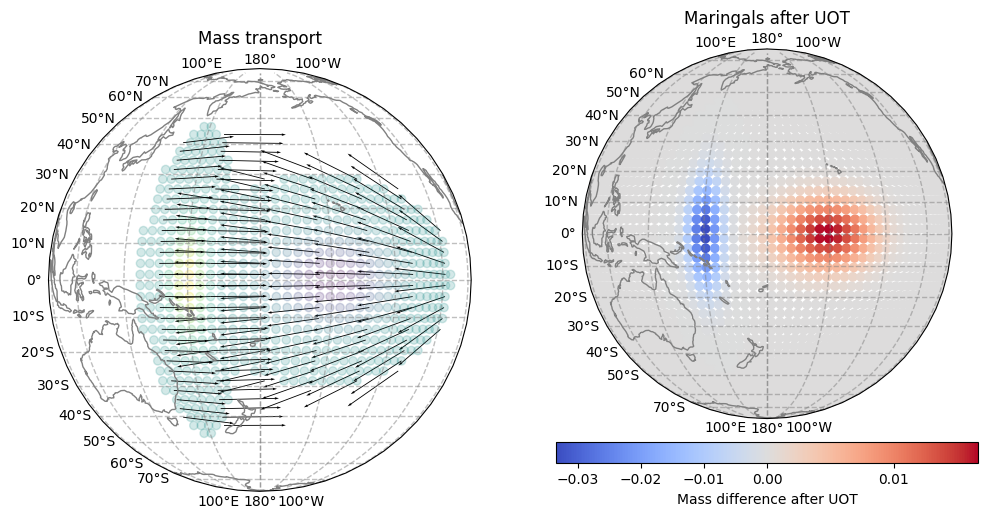

In [14]:
fig = plt.figure(figsize=(12, 6))


ax1 = fig.add_subplot(
    1, 2, 1, 
    projection=ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
)
ax1.set_global()

ax2 = fig.add_subplot(
    1, 2, 2, 
    projection=ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
)
ax2.set_global()
ax1.set_title("Mass transport")
ax2.set_title("Maringals after UOT")

mask = (f1 > 1e-3) | (f2 > 1e-3)

# Flatten
lon_f = Lon[mask]
lat_f = Lat[mask]
val_f = f1[mask] - f2[mask]  # example scalar field
norm = TwoSlopeNorm(
    vmin=np.nanmin(val_f*cell_area[mask]),
    vcenter=0.0,
    vmax=np.nanmax(val_f*cell_area[mask])
)

lon = np.arctan2(X[:,1], X[:,0])
lat = np.arcsin(X[:,2] / np.linalg.norm(X, axis=1))

# local basis
east = np.stack([-np.sin(lon), np.cos(lon), np.zeros_like(lon)], axis=1)
north = np.stack([
    -np.sin(lat)*np.cos(lon),
    -np.sin(lat)*np.sin(lon),
     np.cos(lat)
], axis=1)

datasets = [
    (ax1, X_obs, v0_obs),
    (ax1, X_fcst, v0_fcst),
]

step = 5

for ax, X, V in datasets:

    lon = np.arctan2(X[:,1], X[:,0])
    lat = np.arcsin(X[:,2] / np.linalg.norm(X, axis=1))

    east = np.stack(
        [-np.sin(lon), np.cos(lon), np.zeros_like(lon)],
        axis=1
    )
    north = np.stack(
        [-np.sin(lat)*np.cos(lon),
         -np.sin(lat)*np.sin(lon),
          np.cos(lat)],
        axis=1
    )

    u = np.sum(V * east, axis=1)
    v = np.sum(V * north, axis=1)

    sl = slice(None, None, step)
    norm = TwoSlopeNorm(
        vmin=np.nanmin((f1 - f2).flatten()*cell_area.flatten()),
        vcenter=0.0,
        vmax=np.nanmax((f1 - f2).flatten()*cell_area.flatten())
    )
    ax.scatter(
        lon_f,
        lat_f,
        c=val_f*cell_area[mask].flatten(),
        norm=norm,
        transform=ccrs.PlateCarree(),
        alpha=0.1
    )

    ax.quiver(
        np.rad2deg(lon[sl]),
        np.rad2deg(lat[sl]),
        u[sl],
        v[sl],
        transform=ccrs.PlateCarree(),
        scale=5,
        width=0.002,
        cmap="cividis_r",
    )



# Add coastlines
ax.coastlines(resolution='110m', color='grey', linestyle='-', alpha=1)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlocator = mticker.FixedLocator(list(np.arange(-180, 181, 20)))
gl.ylocator = mticker.FixedLocator(list(np.arange(-90, 91, 10)))

norm = TwoSlopeNorm(
        vmin=np.nanmin((output1 - output2).cpu().numpy()),
        vcenter=0.0,
        vmax=np.nanmax((output1 - output2).cpu().numpy())
    )
p = ax2.scatter(
    Lon.flatten(),
    Lat.flatten(),
    c=(output1 - output2).cpu().numpy(),
    norm=norm,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
)

plt.colorbar(p, ax=ax2, orientation='horizontal', pad=0.05, label='Mass difference after UOT')

# Add coastlines
ax2.coastlines(resolution='110m', color='grey', linestyle='-', alpha=1)

# Add gridlines
gl = ax2.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlocator = mticker.FixedLocator(list(np.arange(-180, 181, 20)))
gl.ylocator = mticker.FixedLocator(list(np.arange(-90, 91, 10)))

plt.show()
# fig.savefig('gaussian_earth.png', dpi=300)
# plt.close()
